In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


# Exploring Data

In [2]:
sp_tracks=pd.read_csv('/kaggle/input/spotify05/tracks.csv')
sp_features=pd.read_csv('/kaggle/input/spotify05/SpotifyFeatures.csv')

In [3]:
sp_tracks.head(5)

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [4]:
sp_tracks.shape

(586672, 20)

In [5]:
sp_tracks.columns

Index(['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

in below It will show how many non-null values there are, in the name column there are some null values.

In [6]:
sp_tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          58

below only in the name column are there 71 null values.

In [7]:
sp_tracks.isnull().sum()

id                   0
name                71
popularity           0
duration_ms          0
explicit             0
artists              0
id_artists           0
release_date         0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
dtype: int64

Here we can see where the null value contains.

In [8]:
sp_tracks[sp_tracks['name'].isnull()]

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
226336,4iH7negBYMfj2z0wDNmgdx,NaN,28,264973,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1994-01-01,0.512,0.578,0,-12.280,0,0.0299,0.0433,0.000064,0.5160,0.692,156.465,1
510975,04d5kbLvSAIBt3pGcljdhC,NaN,0,184293,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.426,0.285,11,-11.970,1,0.0466,0.9950,0.264000,0.2930,0.583,135.661,4
510976,05tRkgyxVdwMePGqOXMDYU,NaN,0,191587,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.344,0.186,0,-13.495,1,0.0745,0.9950,0.000000,0.1150,0.290,79.591,1
510978,0YAMRgAQH6tkTh4sWNXr8L,NaN,0,191573,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.316,0.257,3,-13.611,0,0.0549,0.9950,0.769000,0.5190,0.529,68.682,3
510979,1K6MQQxmFpPb66ZnaiIpHX,NaN,0,167602,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.558,0.283,1,-12.847,1,0.0646,0.9960,0.000000,0.4530,0.608,70.379,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517206,6OH9mz9aFbGlbf74cBwYWD,NaN,2,209760,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1962-02-01,0.506,0.598,7,-4.672,0,0.0635,0.7710,0.000001,0.6910,0.800,91.172,4
517215,15RqFDA86slfzujSQMEX4i,NaN,2,257280,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1962-02-01,0.612,0.615,5,-5.609,1,0.0551,0.8540,0.000023,0.0541,0.809,90.536,4
520127,0hKA9A2JPtFdg0fiMhyjQD,NaN,6,194081,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1974-12-31,0.471,0.369,4,-12.927,0,0.1460,0.9680,0.001100,0.1410,0.766,94.063,4
525238,1kR4gIb7nGxHPI3D2ifs59,NaN,26,289440,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1998-01-05,0.501,0.583,7,-9.460,0,0.0605,0.6900,0.003960,0.0747,0.734,138.391,4


In [9]:
sp_features.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [10]:
sp_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [11]:
sp_features.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [12]:
sp_features.isnull().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [13]:
sp_features[sp_features['track_name'].isnull()]

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
208285,World,Elevation Worship,NaN,7BGQCe62A58Q5ZgpQFX93t,44,0.019,0.287,350027,0.446,0.0,F,0.1,-7.214,Major,0.0317,138.727,4/4,0.0387


In [14]:
sp_tracks['popularity'].max(),sp_tracks['popularity'].min()

(100, 0)

In [15]:
sp_tracks[sp_tracks['popularity']==sp_tracks['popularity'].max()]

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
93802,4iJyoBOLtHqaGxP12qzhQI,Peaches (feat. Daniel Caesar & Giveon),100,198082,1,"['Justin Bieber', 'Daniel Caesar', 'Giveon']","['1uNFoZAHBGtllmzznpCI3s', '20wkVLutqVOYrc0kxF...",2021-03-19,0.677,0.696,0,-6.181,1,0.119,0.321,0.0,0.42,0.464,90.03,4


# Frequency Analysis of Track Popularity

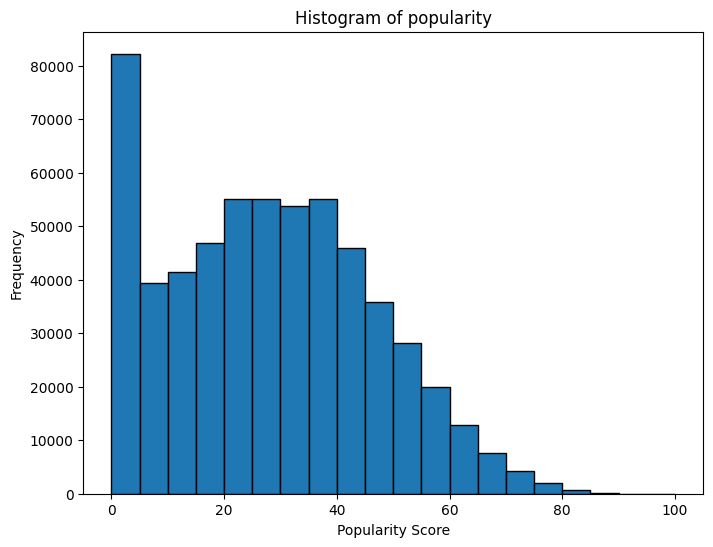

In [16]:
plt.figure(figsize=(8,6))
plt.hist(sp_tracks['popularity'],bins=20,edgecolor='k')
plt.title("Histogram of popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Frequency")
plt.show()

# Leaderboard: Spotify's Most Popular Songs by Score

In [17]:
top10 = sp_tracks[sp_tracks['popularity'] >= 90].copy()

# Sort the values 
top10.sort_values('popularity', ascending=False, inplace=True)

#  Display the top 10
top10[['name', 'popularity', 'artists']].head(10)

,name,popularity,artists
93802,Peaches (feat. Daniel Caesar & Giveon),100,"['Justin Bieber', 'Daniel Caesar', 'Giveon']"
93803,drivers license,99,['Olivia Rodrigo']
93804,Astronaut In The Ocean,98,['Masked Wolf']
92810,Save Your Tears,97,['The Weeknd']
92811,telepatía,97,['Kali Uchis']
93805,Leave The Door Open,96,"['Bruno Mars', 'Anderson .Paak', 'Silk Sonic']"
92813,Blinding Lights,96,['The Weeknd']
92814,The Business,95,['Tiësto']
91866,Streets,94,['Doja Cat']
93807,Friday (feat. Mufasa & Hypeman) - Dopamine Re-...,94,"['Riton', 'Nightcrawlers', 'Mufasa & Hypeman',..."


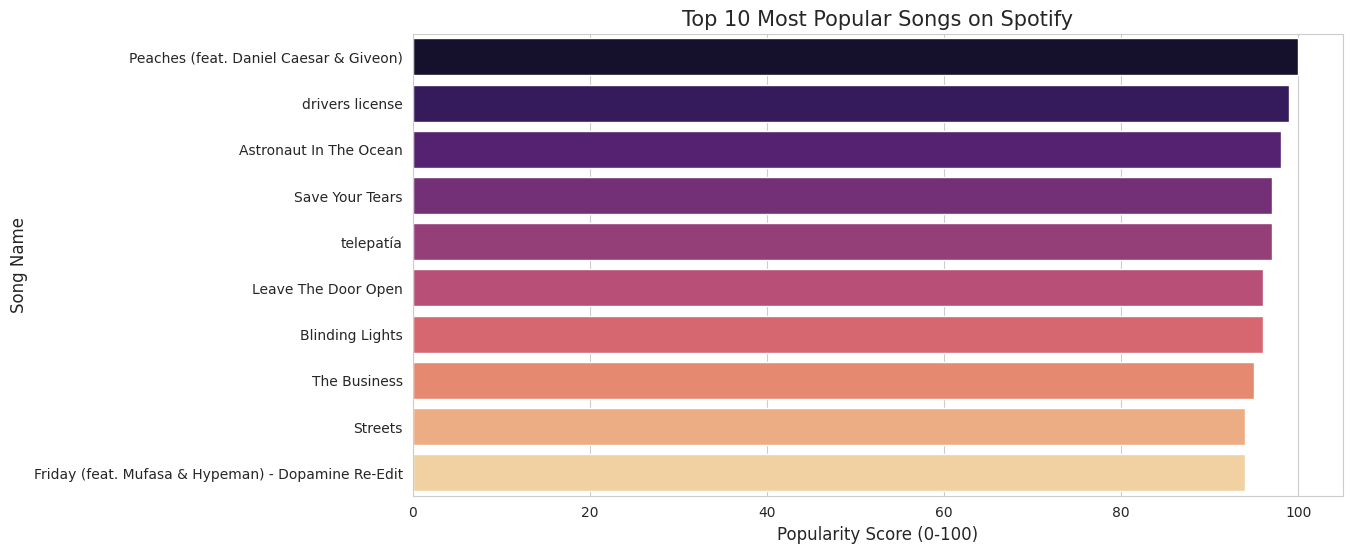

In [18]:
# Set the visual style
sns.set_style("whitegrid")

# Create the plot - added .head(10) here
plt.figure(figsize=(12, 6))
sns.barplot(x='popularity', y='name', data=top10.head(10), palette='magma')

# Add titles and labels
plt.title('Top 10 Most Popular Songs on Spotify', fontsize=15)
plt.xlabel('Popularity Score (0-100)', fontsize=12)
plt.ylabel('Song Name', fontsize=12)

# Display the plot
plt.show()

# The Evolution of the Library: Annual Release Trends

In [19]:
# Convert release_date to datetime, handling mixed formats (years only vs full dates)
sp_tracks['release_date'] = pd.to_datetime(sp_tracks['release_date'], format='mixed')

# Extract the year
sp_tracks['year'] = sp_tracks['release_date'].dt.year

# Count songs per year
yearly_counts = sp_tracks['year'].value_counts().sort_index()

# Display the first few rows of the result
print(yearly_counts.head())

year
1900      1
1922    294
1923    657
1924    633
1925    903
Name: count, dtype: int64


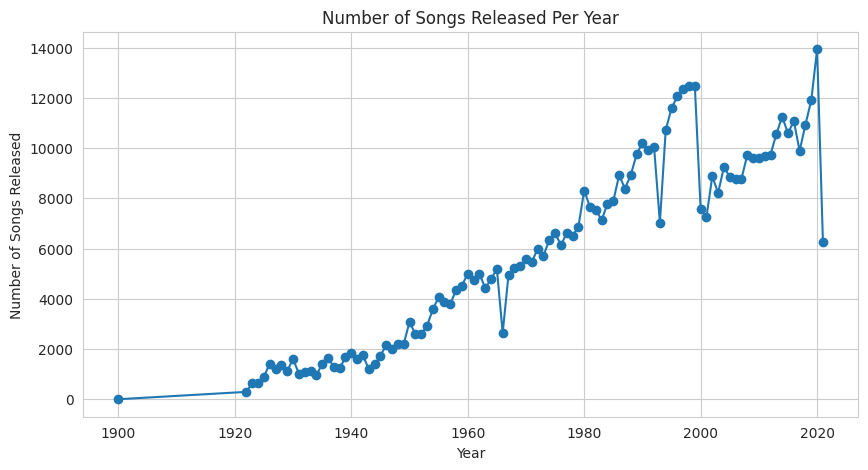

In [20]:
yearly_counts = sp_tracks.groupby('year')['id'].count()

plt.figure(figsize=(10, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', linestyle='-')

# Labels and title
plt.xlabel("Year")
plt.ylabel("Number of Songs Released")
plt.title("Number of Songs Released Per Year")
plt.grid(True)

# Show the plot
plt.show()

# Distribution of Audio Features

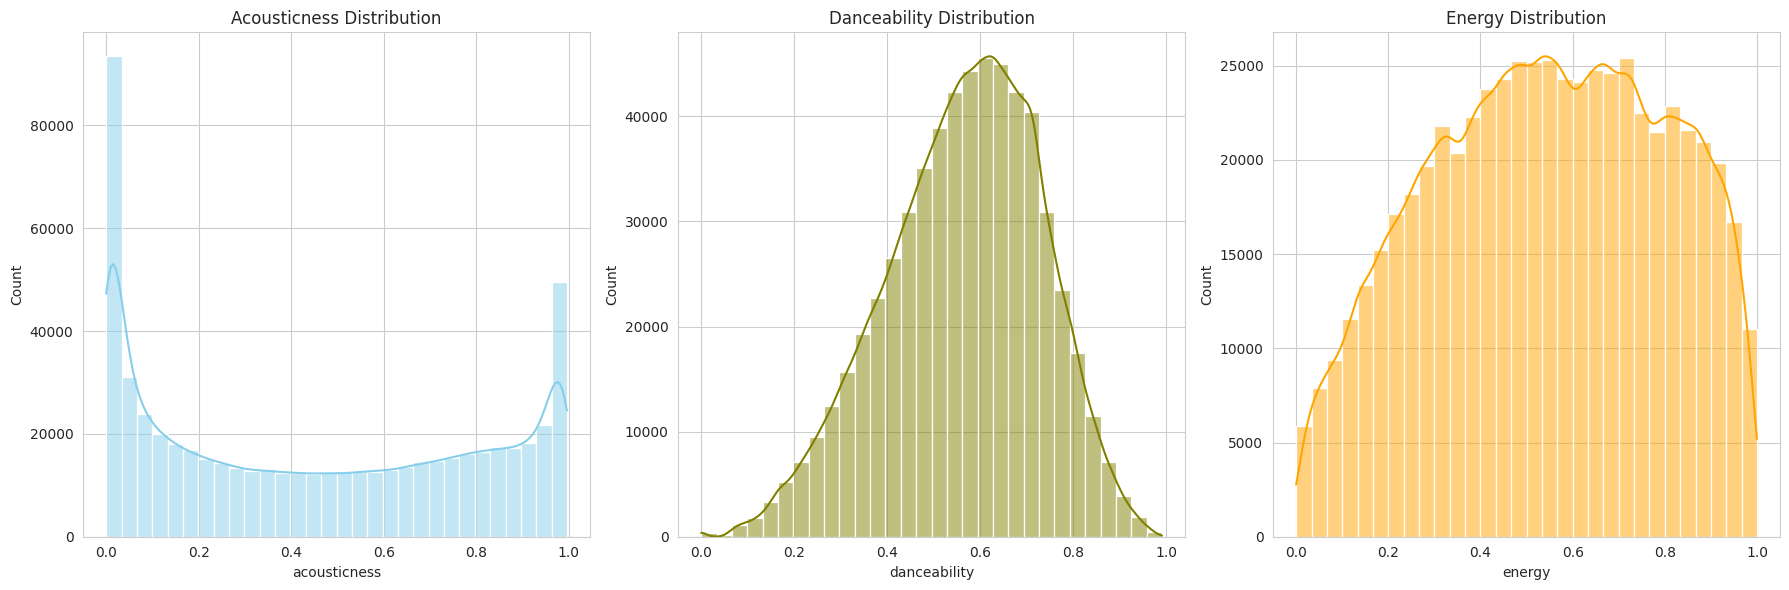

In [21]:
warnings.filterwarnings("ignore", category=FutureWarning)
# Set the style
sns.set_style("whitegrid")

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Acousticness
sns.histplot(sp_tracks['acousticness'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Acousticness Distribution')

# Plot Danceability
sns.histplot(sp_tracks['danceability'], bins=30, kde=True, ax=axes[1], color='olive')
axes[1].set_title('Danceability Distribution')

# Plot Energy
sns.histplot(sp_tracks['energy'], bins=30, kde=True, ax=axes[2], color='orange')
axes[2].set_title('Energy Distribution')

plt.tight_layout()
plt.show()

# Quantifying Artist Impact: Productivity vs. Global Popularity

In [22]:
# Group by artist and calculate mean popularity and count of tracks
artist_analysis = sp_tracks.groupby('artists').agg(
    avg_popularity=('popularity', 'mean'),
    track_count=('id', 'count')
).reset_index()

# Filter for artists with at least 50 tracks to avoid "one-hit wonders" 
# having a high average from just one song
influential_artists = artist_analysis[artist_analysis['track_count'] >= 50].sort_values(by='avg_popularity', ascending=False)

# Display top 10
influential_artists.head(10)

,artists,avg_popularity,track_count
75636,['One Direction'],68.226804,97
99998,['The Weeknd'],66.385714,70
102801,['Twenty One Pilots'],64.709091,55
2974,['Adele'],63.450000,60
8227,['Ariana Grande'],63.308824,68
27128,['Drake'],62.689320,103
10366,['BLACKPINK'],62.323529,68
51483,['Juice WRLD'],61.018519,54
84620,['Rihanna'],60.901099,91
53205,['Kanye West'],60.835294,85


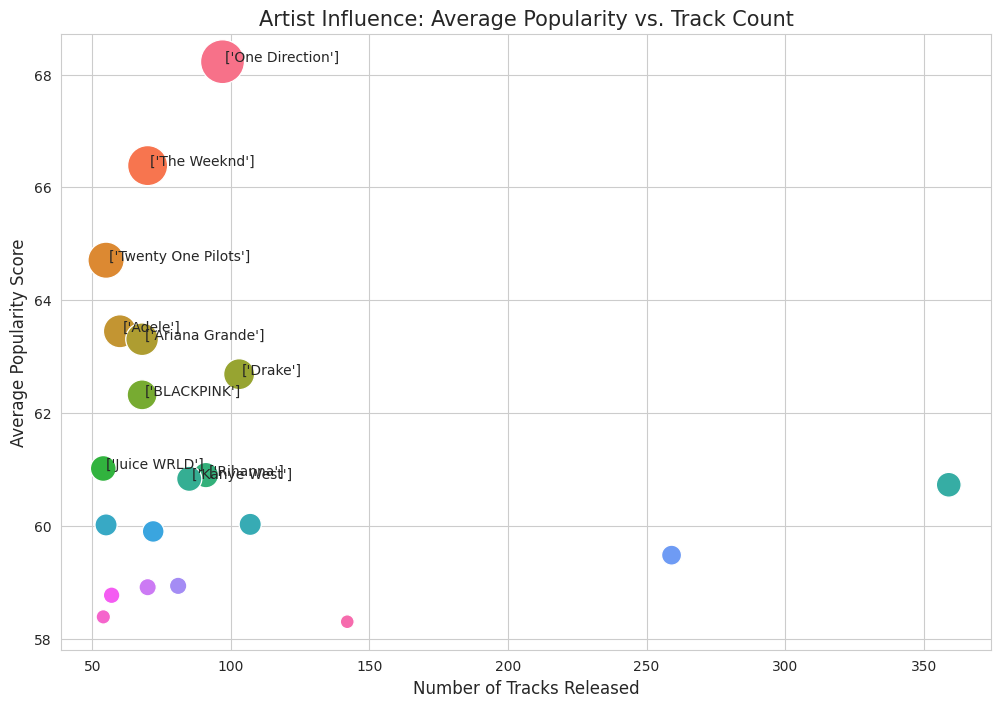

In [23]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=influential_artists.head(20), 
                x='track_count', 
                y='avg_popularity', 
                size='avg_popularity', 
                hue='artists', 
                legend=False,
                sizes=(100, 1000))

# Add labels to the bubbles
for i in range(10):
    plt.text(influential_artists.track_count.iloc[i]+1, 
             influential_artists.avg_popularity.iloc[i], 
             influential_artists.artists.iloc[i], 
             fontsize=10)

plt.title('Artist Influence: Average Popularity vs. Track Count', fontsize=15)
plt.xlabel('Number of Tracks Released', fontsize=12)
plt.ylabel('Average Popularity Score', fontsize=12)
plt.show()

# Popularity Trends by Musical Genre

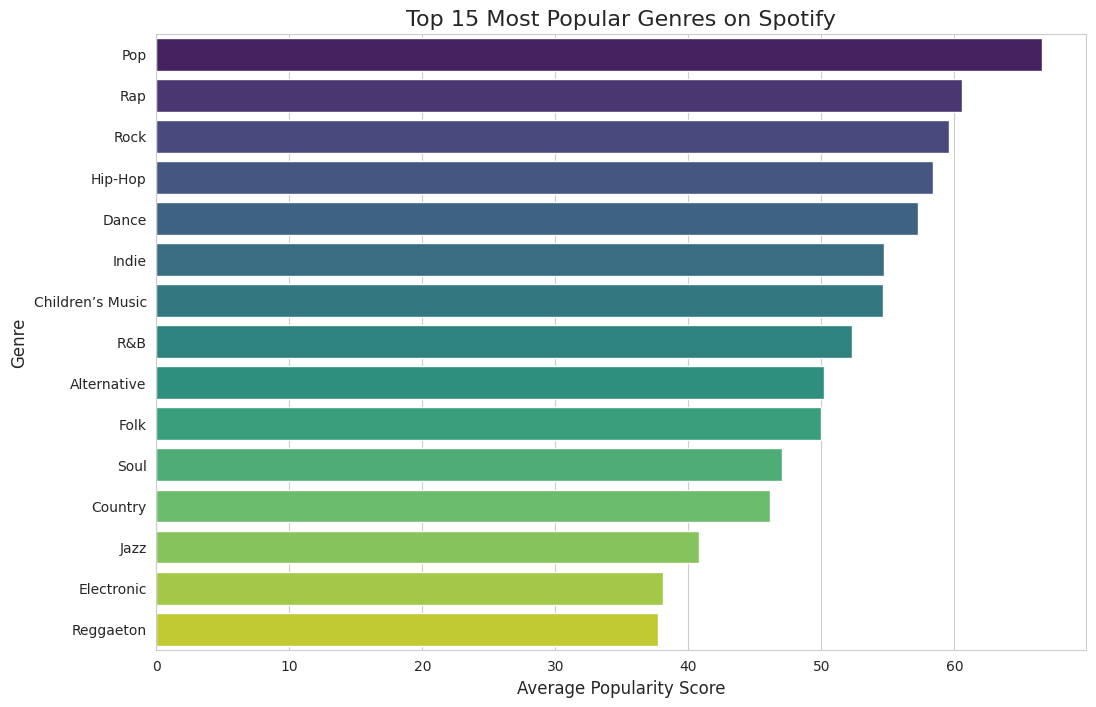

In [24]:

# Calculate Average Popularity per Genre
genre_popularity = sp_features.groupby('genre')['popularity'].mean().sort_index()

# Calculate Track Count per Genre (Market Share)
genre_count = sp_features.groupby('genre')['track_id'].count().sort_index()

# Combine into a single DataFrame for easy plotting
genre_analysis = pd.DataFrame({
    'Average Popularity': genre_popularity,
    'Track Count': genre_count
}).sort_values(by='Average Popularity', ascending=False)

# Visualization: Top 10 Dominant Genres
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_analysis['Average Popularity'].head(15), 
            y=genre_analysis.index[:15], 
            palette='viridis')

plt.title('Top 15 Most Popular Genres on Spotify', fontsize=16)
plt.xlabel('Average Popularity Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

# Decoding Genre DNA: Audio Feature Variance in Rock, Hip-Hop, and Classical

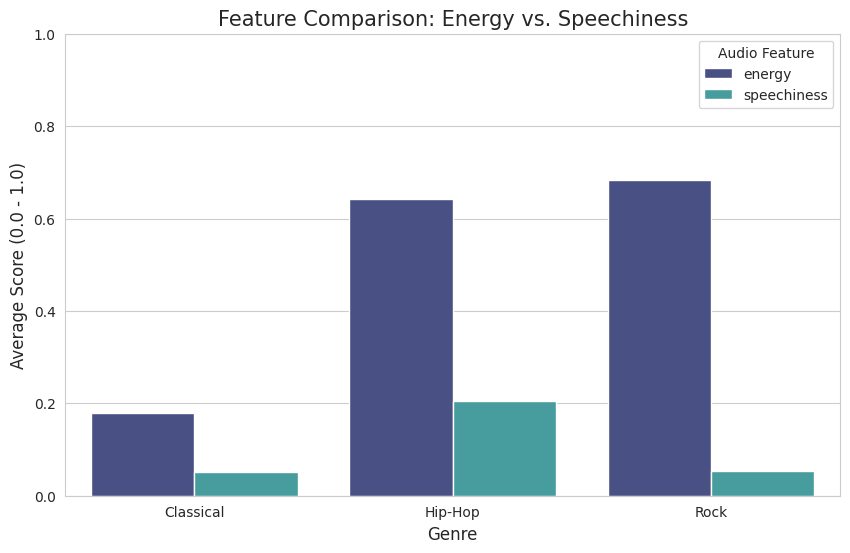

In [25]:
# Filter the dataset for the specific genres
target_genres = ['Hip-Hop', 'Classical', 'Rock']
comparison_df = sp_features[sp_features['genre'].isin(target_genres)]

# Calculate the mean for Energy and Speechiness
genre_comparison = comparison_df.groupby('genre')[['energy', 'speechiness']].mean().reset_index()

# Reshape the data for a grouped bar chart (melting)
melted_comparison = genre_comparison.melt(id_vars='genre', var_name='Feature', value_name='Value')

# Create the Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_comparison, x='genre', y='Value', hue='Feature', palette='mako')

plt.title('Feature Comparison: Energy vs. Speechiness', fontsize=15)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1) # Features are on a 0-1 scale
plt.legend(title='Audio Feature')
plt.show()

# Average song duration Time

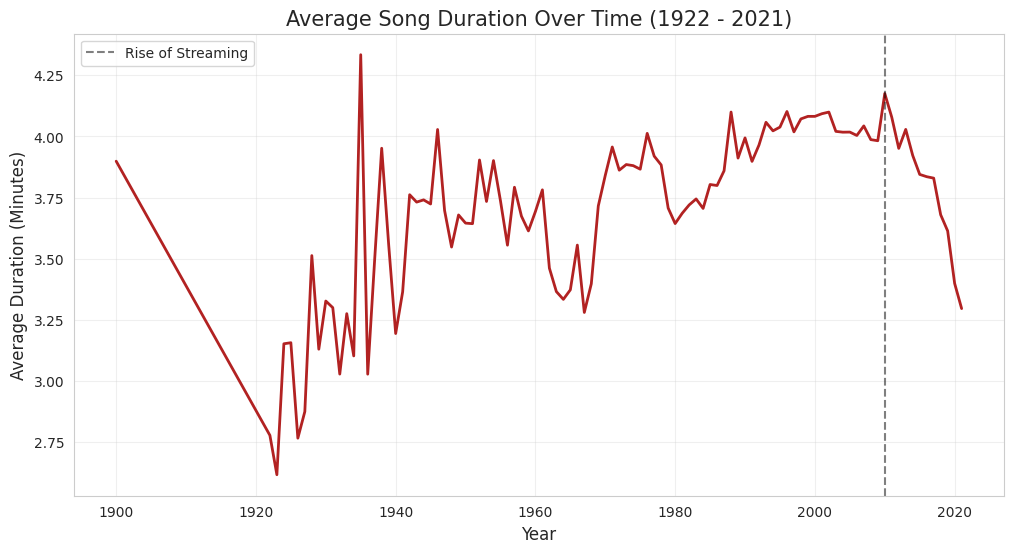

In [26]:
# Convert duration from milliseconds to minutes for easier reading
sp_tracks['duration_mins'] = sp_tracks['duration_ms'] / 60000

# Group by year and calculate the mean duration
duration_year = sp_tracks.groupby('year')['duration_mins'].mean()

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(duration_year.index, duration_year.values, color='firebrick', linewidth=2)

# Adding a vertical line for the "Streaming Era" (approx 2010)
plt.axvline(x=2010, color='black', linestyle='--', alpha=0.5, label='Rise of Streaming')

plt.title('Average Song Duration Over Time (1922 - 2021)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Duration (Minutes)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Conclusion: Insights from the Spotify Ecosystem
Through this exploratory data analysis, we have uncovered several key trends that define the modern music landscape on Spotify:

The "Hit" Phenomenon: Our popularity distribution and Top 10 analysis reveal a Power Law effect. While the dataset contains hundreds of thousands of tracks, only a tiny fraction (less than 1%) achieve a popularity score above 90. Success on the platform is highly concentrated among a few "mega-hits."

Artist Consistency vs. Volume: By analyzing artist productivity, we found that high-output isn't the only path to success. Artists like The Weeknd and Ariana Grande maintain incredibly high average popularity across their entire discography, suggesting that brand consistency is a stronger predictor of success than sheer track volume.

The Shrinking Song: One of the most significant historical trends identified is the decline in average song duration. Since the rise of the streaming era (around 2010), song lengths have trended downward, likely to optimize for replayability and the platform's "pay-per-stream" model.

Genre DNA: Our comparison of audio features shows that genres are mathematically distinct. Hip-Hop is characterized by high speechiness and energy, whereas Classical music occupies the opposite end of the spectrum with high acousticness and low energy.

Acoustic vs. Electronic: The distribution of audio features suggests that the library is currently balanced between organic (acoustic) and synthesized (high-energy/danceable) sounds, catering to a wide variety of listener moods.

Final Thought
The data suggests that while musical diversity is at an all-time high, the "streaming effect" is actively reshaping how songs are composed and consumed—favoring shorter, more energetic tracks that capture attention quickly in a competitive digital marketplace.**